In [11]:
import pandas as pd
import statsmodels.api as sm    
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

In [12]:
my_data_dir = '/home/rmhihbp/my_ukb_thesis/data'
load_path = os.path.join(my_data_dir, 'group_1_model_ready.parquet')
df_model = pd.read_parquet(load_path)
print(f'shape of df_model: {df_model.shape}')
print(f'columns of df_model: {df_model.columns}')

shape of df_model: (459142, 16)
columns of df_model: Index(['def_CVD_AF_HF_AFTER', 'age_defined_baseline', 'genetic_sex', 'BMI',
       'diet_total', 'sleep_hours', 'device_computer', 'mental_doctor',
       'mental_risk', 'mobile_1', 'mobile_2', 'mobile_3', 'mobile_4',
       'smoking_1', 'smoking_2', 'eid'],
      dtype='object')


In [13]:
target_col = 'def_CVD_AF_HF_AFTER'
feature_cols = ['diet_total',  
                'sleep_hours', 'smoking_1', 'smoking_2',
                'mobile_1', 'mobile_2', 'mobile_3', 'mobile_4', 
                'device_computer', 'mental_doctor', 'mental_risk']
model_cols = ['age_defined_baseline', 'genetic_sex','BMI'] + feature_cols # age, sex, BMI + feature columns

# clean data for modeling
model_data = df_model[[target_col] + model_cols].dropna()

X = model_data[model_cols] # features
Y = model_data[target_col] # target variable   

X = sm.add_constant(X) # add intercept
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # split into train and test sets
print(f'training samples: {len(X_train)}, testing samples: {len(X_test)}, total samples: {len(model_data)}')

training samples: 343292, testing samples: 85824, total samples: 429116


In [14]:
logit_model = sm.Logit(Y_train, X_train).fit(disp=0) # fit logistic regression model

print(logit_model.summary())

# calculate odds ratios and confidence intervals
print("\n=== (Odds Ratios) ===")
params = logit_model.params
conf = logit_model.conf_int()
conf['OR'] = params
conf.columns = ['Lower CI', 'Upper CI', 'Odds Ratio']

result_table = np.exp(conf)
result_table['P-value'] = logit_model.pvalues
print(result_table.sort_values(by='P-value',ascending=True))

                            Logit Regression Results                           
Dep. Variable:     def_CVD_AF_HF_AFTER   No. Observations:               343292
Model:                           Logit   Df Residuals:                   343277
Method:                            MLE   Df Model:                           14
Date:                 Sun, 22 Feb 2026   Pseudo R-squ.:                 0.08556
Time:                         21:57:18   Log-Likelihood:                -93216.
converged:                        True   LL-Null:                   -1.0194e+05
Covariance Type:             nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -9.4859      0.082   -115.194      0.000      -9.647      -9.324
age_defined_baseline     0.0901      0.001     93.701      0.000       0.088       0.092
gene

Testing AUC Score: 0.7223
Training AUC Score: 0.7221


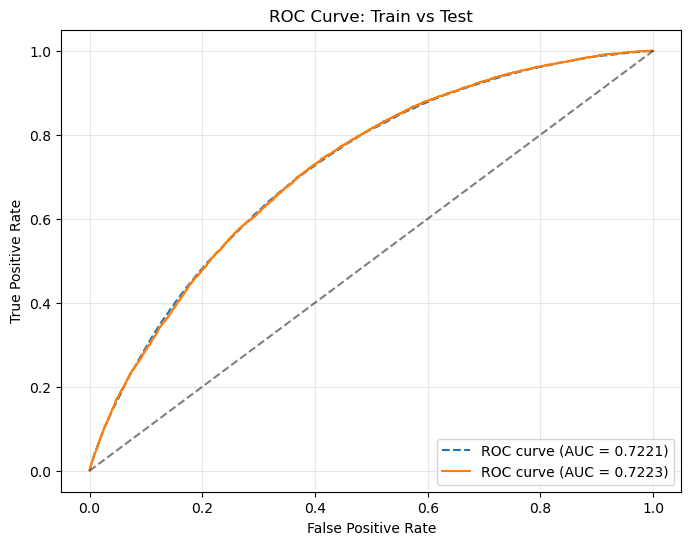

In [15]:
y_test_prob = logit_model.predict(X_test) # predict probabilities on test set
y_train_prob = logit_model.predict(X_train) # predict probabilities on training set

auc_test = roc_auc_score(Y_test, y_test_prob) # calculate AUC score for testing set
auc_train = roc_auc_score(Y_train, y_train_prob) # calculate AUC score for training set

print(f'Testing AUC Score: {auc_test:.4f}')
print(f'Training AUC Score: {auc_train:.4f}')

fpr_test, tpr_test, thresholds = roc_curve(Y_test, y_test_prob) # calculate false positive rate and true positive rate for testing ROC curve
fpr_train, tpr_train, thresholds = roc_curve(Y_train, y_train_prob) # calculate false positive rate and true positive rate for training ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, linestyle = '--', label=f'ROC curve (AUC = {auc_train:.4f})') # plot training ROC curve
plt.plot(fpr_test, tpr_test, linestyle = '-', label=f'ROC curve (AUC = {auc_test:.4f})') # plot testing ROC curve
plt.plot([0, 1], [0, 1], 'k--', alpha = 0.5) # plot diagonal line for reference
plt.xlabel('False Positive Rate') # label x-axis
plt.ylabel('True Positive Rate') # label y-axis
plt.title('ROC Curve: Train vs Test') # title for the plot
plt.legend(loc='lower right') # show legend
plt.grid(True,alpha=0.3) # add grid
plt.show() # display the plot